# Time Sereis Analysis

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

plt.rcParams["figure.figsize"]=(14,6)

# Load Processed Dataset

In [5]:
# Load Dataset
df = pd.read_csv(r"C:\Users\amans\Downloads\train.csv.zip")

# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Order Date

In [6]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

In [7]:
df = df.sort_values("Order Date")

# Create Monthly Sales Time Series

In [8]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [9]:
ts = monthly_sales.set_index("Order Date")

ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


# Dataset Information

In [10]:
print(ts.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2015-01-31 to 2018-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   48 non-null     float64
dtypes: float64(1)
memory usage: 768.0 bytes
None


In [ ]:
# Dataset describe

In [11]:
print(ts.describe())

               Sales
count      48.000000
mean    47115.349640
std     24978.687305
min      4519.892000
25%     29621.712625
50%     39202.126500
75%     64391.969125
max    117938.155000


# Monthly Sales Trend

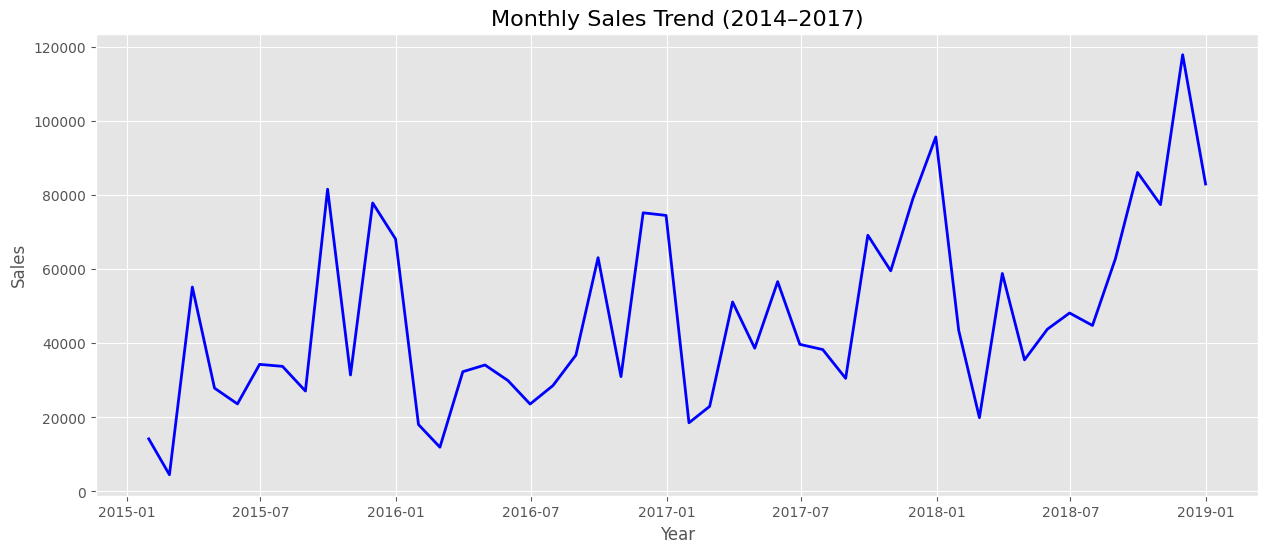

In [12]:
plt.figure(figsize=(15,6))

plt.plot(
    ts.index,
    ts["Sales"],
    color="blue",
    linewidth=2
)

plt.title("Monthly Sales Trend (2014–2017)", fontsize=16)

plt.xlabel("Year")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [13]:
rolling_mean = ts["Sales"].rolling(window=12).mean()

rolling_std = ts["Sales"].rolling(window=12).std()

# Rolling Mean and Rolling Standard Deviation

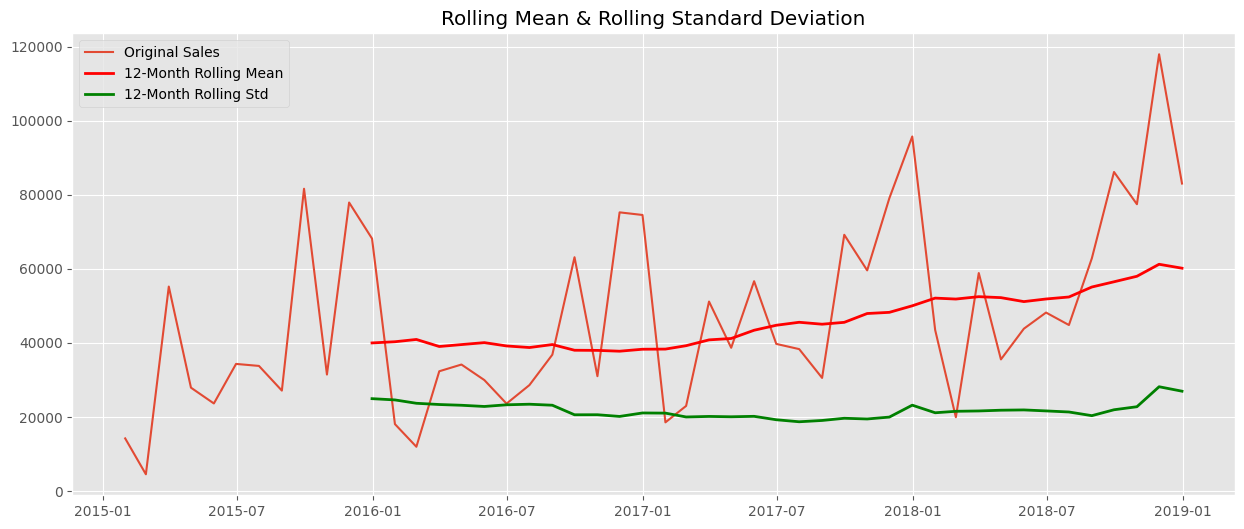

In [14]:
plt.figure(figsize=(15,6))

plt.plot(
    ts.index,
    ts["Sales"],
    label="Original Sales"
)

plt.plot(
    rolling_mean,
    color="red",
    linewidth=2,
    label="12-Month Rolling Mean"
)

plt.plot(
    rolling_std,
    color="green",
    linewidth=2,
    label="12-Month Rolling Std"
)

plt.title("Rolling Mean & Rolling Standard Deviation")

plt.legend()

plt.show()

In [15]:
decomposition = seasonal_decompose(
    ts["Sales"],
    model="additive",
    period=12
)

In [16]:
trend = decomposition.trend

seasonal = decomposition.seasonal

residual = decomposition.resid

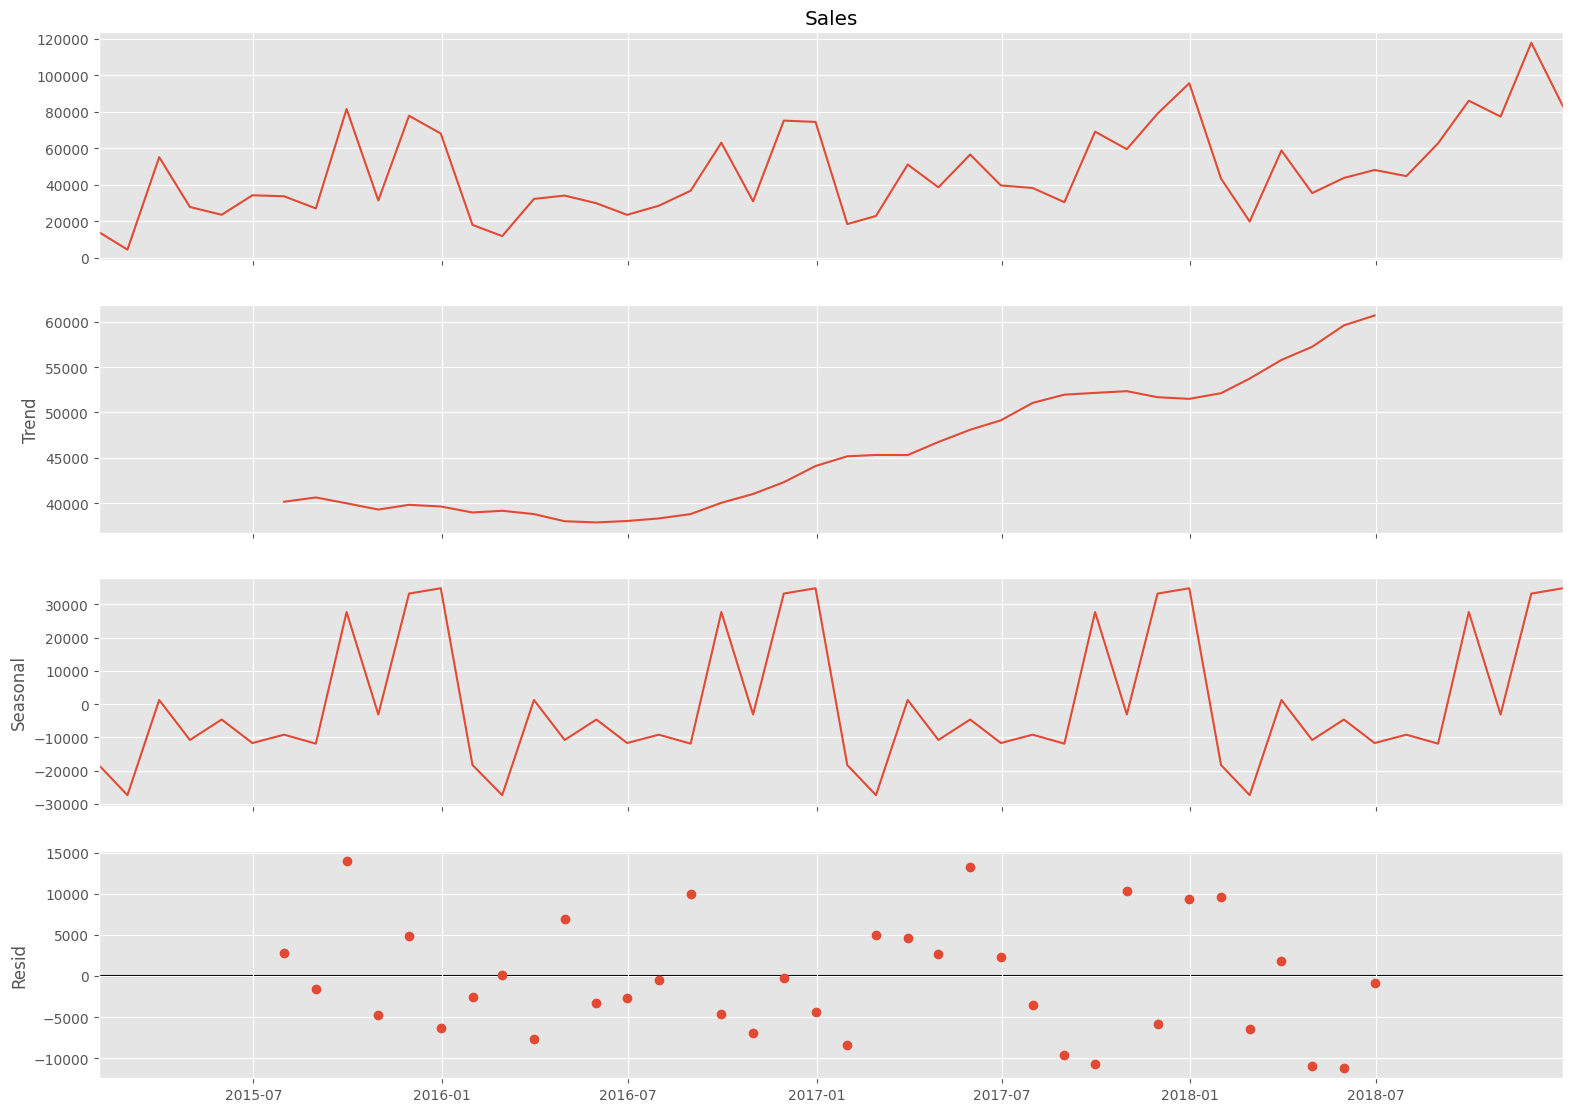

In [17]:
fig = decomposition.plot()

fig.set_size_inches(16,12)

plt.show()

# Trend Component

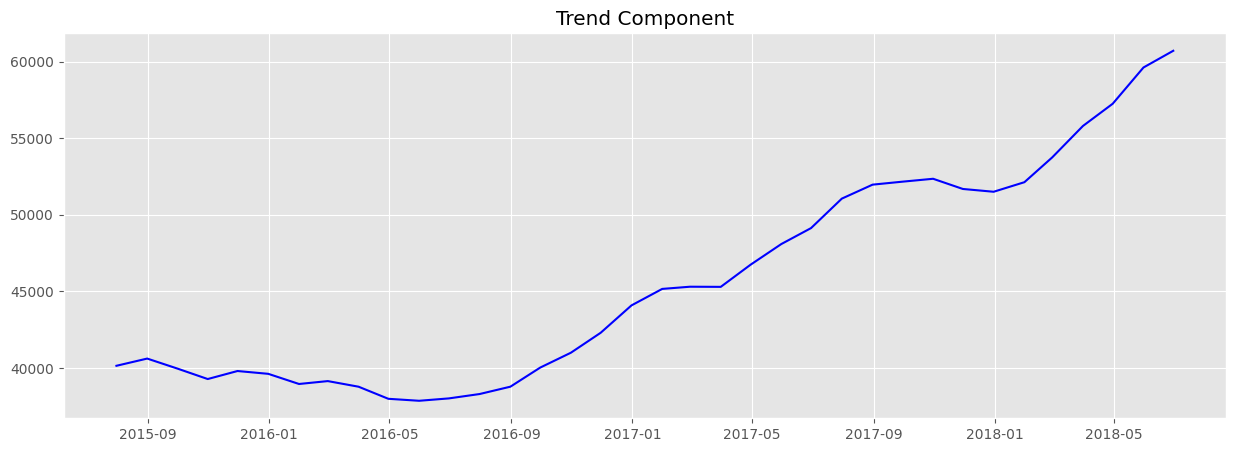

In [18]:
plt.figure(figsize=(15,5))

plt.plot(
    trend,
    color="blue"
)

plt.title("Trend Component")

plt.show()

# Seasonal Component

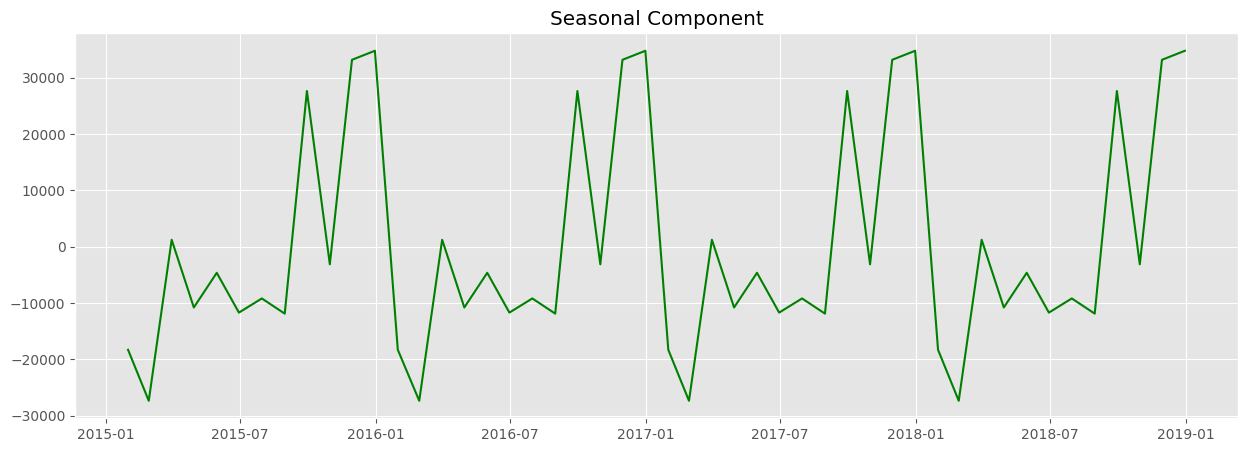

In [19]:
plt.figure(figsize=(15,5))

plt.plot(
    seasonal,
    color="green"
)

plt.title("Seasonal Component")

plt.show()

# Residual Component

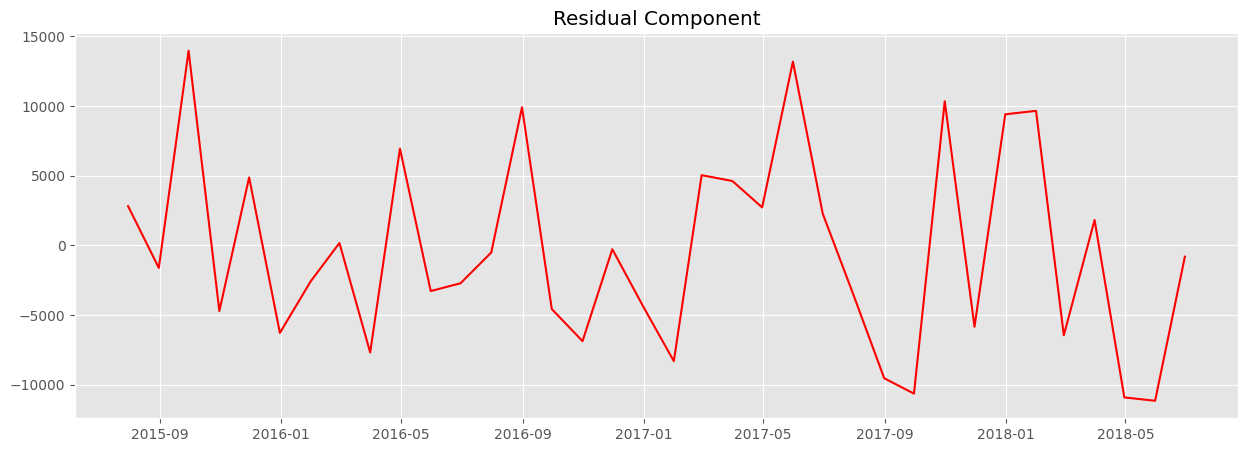

In [20]:
plt.figure(figsize=(15,5))

plt.plot(
    residual,
    color="red"
)

plt.title("Residual Component")

plt.show()

# Augmented Dickey-Fuller (ADF) Test

In [22]:
from statsmodels.tsa.stattools import adfuller

In [24]:
def adf_test(series):

    result = adfuller(series.dropna())

    labels = [
        "ADF Test Statistic",
        "p-value",
        "# Lags Used",
        "Number of Observations"
    ]

    print("="*60)
    print("Augmented Dickey-Fuller Test")
    print("="*60)

    for value, label in zip(result[:4], labels):
        print(f"{label}: {value}")

    print("\nCritical Values")

    for key, value in result[4].items():
        print(f"{key}: {value}")

    if result[1] <= 0.05:
        print("\nResult:")
        print("The time series is Stationary.")
    else:
        print("\nResult:")
        print("The time series is Non-Stationary.")

In [25]:
adf_test(ts["Sales"])

Augmented Dickey-Fuller Test
ADF Test Statistic: -4.416136761430769
p-value: 0.00027791039276670623
# Lags Used: 0
Number of Observations: 47

Critical Values
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064

Result:
The time series is Stationary.


In [27]:
ts_diff = ts["Sales"].diff()

In [28]:
ts_diff = ts_diff.dropna()

ts_diff.head()

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Name: Sales, dtype: float64

# Difference Sales

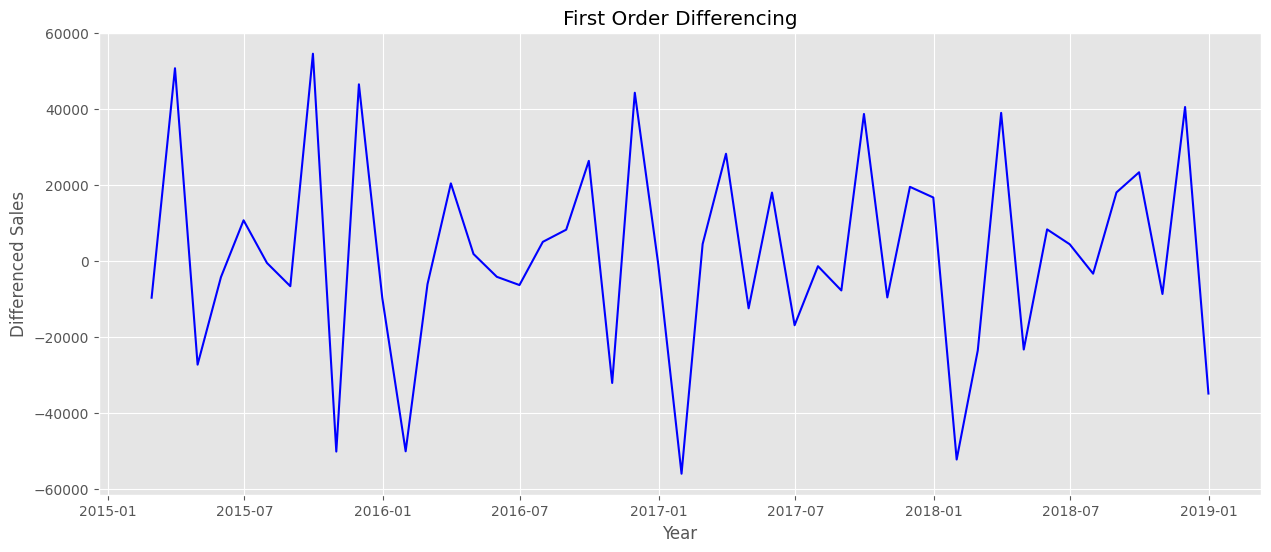

In [29]:
plt.figure(figsize=(15,6))

plt.plot(
    ts_diff,
    color="blue"
)

plt.title("First Order Differencing")

plt.xlabel("Year")

plt.ylabel("Differenced Sales")

plt.grid(True)

plt.show()

In [30]:
rolling_mean_diff = ts_diff.rolling(12).mean()

rolling_std_diff = ts_diff.rolling(12).std()

# Rolling Statistics After Differencing 

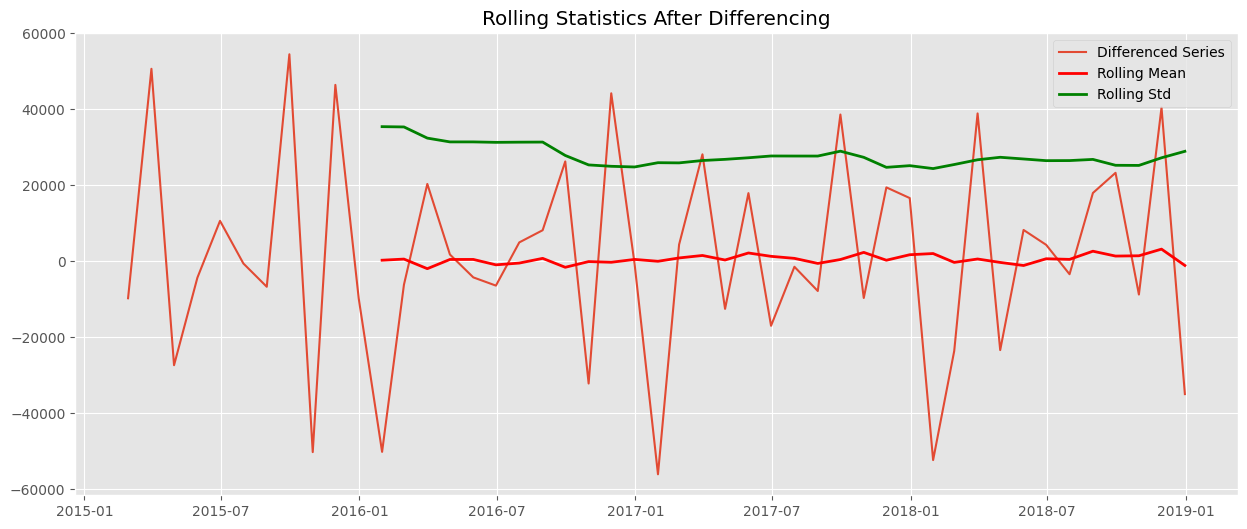

In [31]:
plt.figure(figsize=(15,6))

plt.plot(
    ts_diff,
    label="Differenced Series"
)

plt.plot(
    rolling_mean_diff,
    color="red",
    linewidth=2,
    label="Rolling Mean"
)

plt.plot(
    rolling_std_diff,
    color="green",
    linewidth=2,
    label="Rolling Std"
)

plt.legend()

plt.title("Rolling Statistics After Differencing")

plt.show()

In [32]:
adf_test(ts_diff)

Augmented Dickey-Fuller Test
ADF Test Statistic: -8.727061830353257
p-value: 3.266917547279888e-14
# Lags Used: 10
Number of Observations: 36

Critical Values
1%: -3.626651907578875
5%: -2.9459512825788754
10%: -2.6116707716049383

Result:
The time series is Stationary.


# Original vs Differenced Time Series

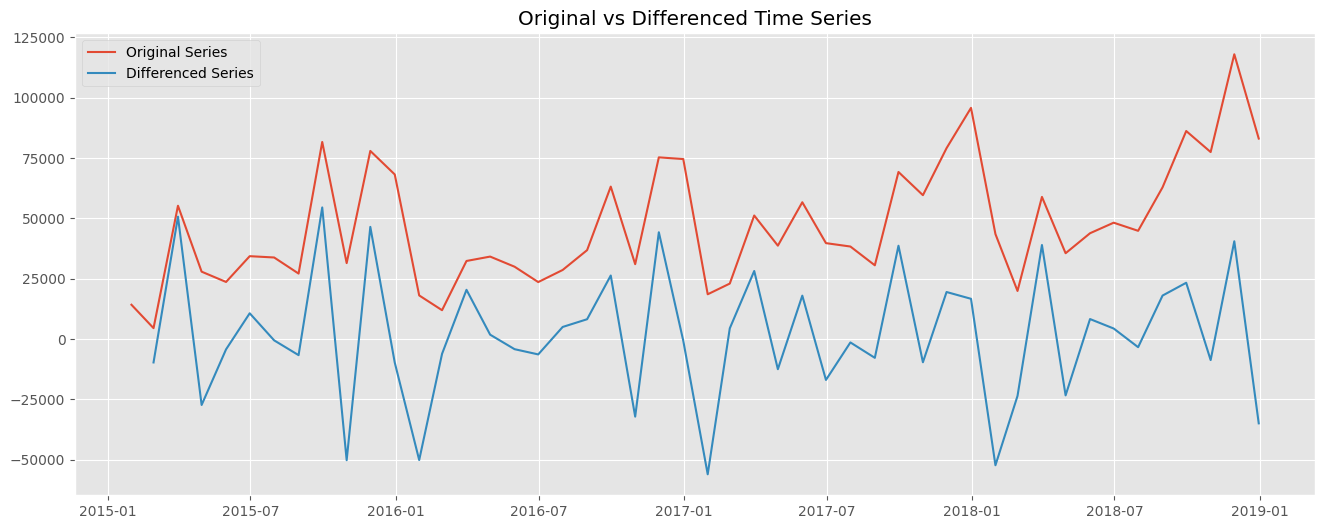

In [33]:
plt.figure(figsize=(16,6))

plt.plot(
    ts["Sales"],
    label="Original Series"
)

plt.plot(
    ts_diff,
    label="Differenced Series"
)

plt.legend()

plt.title("Original vs Differenced Time Series")

plt.show()

In [34]:
ts_diff.to_csv("stationary_sales_series.csv")

# Standard Deviation

In [35]:
summary = pd.DataFrame({

    "Series":[
        "Original",
        "Differenced"
    ],

    "Mean":[
        ts["Sales"].mean(),
        ts_diff.mean()
    ],

    "Standard Deviation":[
        ts["Sales"].std(),
        ts_diff.std()
    ]

})

summary

,Series,Mean,Standard Deviation
0,Original,47115.349640,24978.687305
1,Differenced,1464.354932,27304.081997
